# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name:Sneha M A
### Date:29-Sep-2016

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [107]:
# TODO: shape, dtypes, missing value summary
df.shape

(48895, 16)

In [108]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [109]:
df["last_review"]=pd.to_datetime(df['last_review'])

In [110]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [112]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [113]:
# TODO: check for values that are technically present but don't make real-world sense
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


In [114]:
# TODO: duplicate check
df.duplicated().sum()

np.int64(0)

**Written notes — what did you find, and what looks suspicious?**

there are missing values
no duplicates

---
## Part 2 — Missing Value Diagnosis & Treatment

In [115]:
df=df.drop(columns=['last_review'])

In [116]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


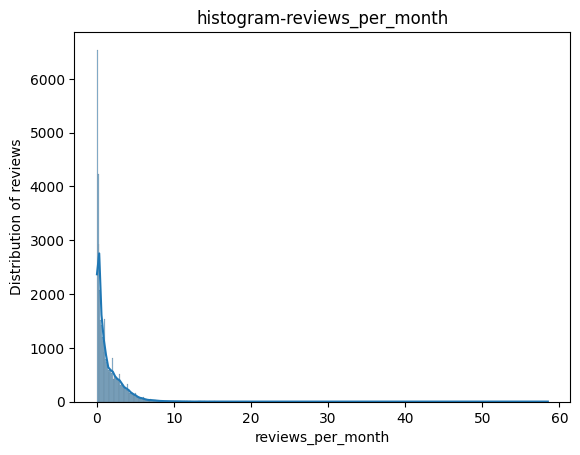

In [117]:
# TODO: investigate missingness pattern(s) across columns
#missing values in reviews_per_month
sns.histplot(df["reviews_per_month"],kde=True)
plt.xlabel('reviews_per_month')
plt.ylabel('Distribution of reviews')
plt.title('histogram-reviews_per_month')
plt.show()

**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

it is a skewed histogram hence median is found to fill the missing values

In [118]:
df["reviews_per_month"].median()

0.72

In [119]:
df["reviews_per_month"]=df["reviews_per_month"].fillna(
    df["reviews_per_month"].median()
)

In [120]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [121]:
# TODO: apply your chosen treatment(s)
#now the missing values are obj type so we use mode to fill the values
df = df.drop(columns=["id","name",'host_id',"host_name","latitude","longitude"])
df

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,Private room,150,3,0,0.72,1,365
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,Private room,70,2,0,0.72,2,9
48891,Brooklyn,Bushwick,Private room,40,4,0,0.72,2,36
48892,Manhattan,Harlem,Entire home/apt,115,10,0,0.72,1,27
48893,Manhattan,Hell's Kitchen,Shared room,55,1,0,0.72,6,2


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   room_type                       48895 non-null  object 
 3   price                           48895 non-null  int64  
 4   minimum_nights                  48895 non-null  int64  
 5   number_of_reviews               48895 non-null  int64  
 6   reviews_per_month               48895 non-null  float64
 7   calculated_host_listings_count  48895 non-null  int64  
 8   availability_365                48895 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 3.4+ MB


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

_Your answer here._

---
## Part 3 — Outlier Detection & Treatment

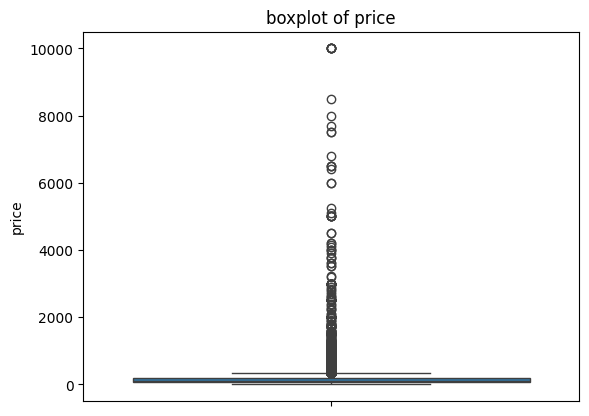

In [123]:
# TODO: detect outliers in at least two numeric columns
sns.boxplot(df['price'])
plt.title("boxplot of price")
plt.show()

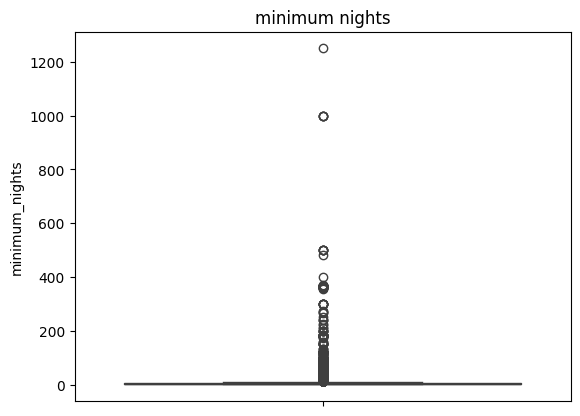

In [124]:
sns.boxplot(df['minimum_nights'])
plt.title("minimum nights")
plt.show()

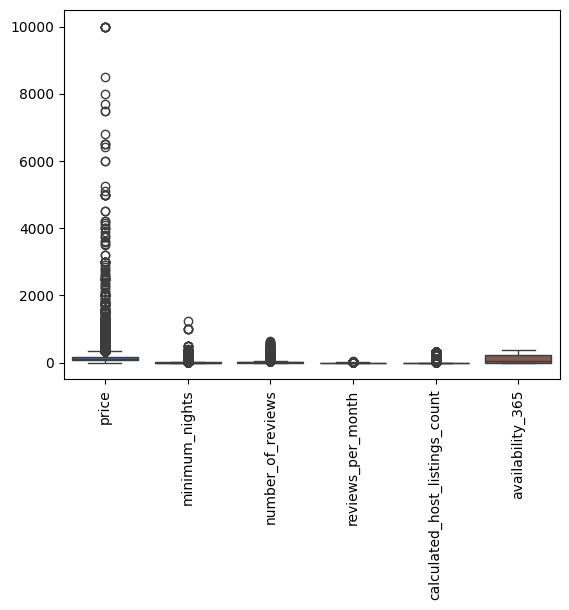

In [125]:
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

_Your answer here._

In [126]:
# TODO: apply treatment consistent with your judgment above
#outliers are treated using IQR method
Q1=df['price'].quantile(0.25)
Q2=df['price'].quantile(0.5)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1

lower_bound_price = Q1- 1.5* IQR
upper_bound_price = Q3+ 1.5 *IQR

Q1_min_nights=df['minimum_nights'].quantile(0.25)
Q3_min_nights=df['minimum_nights'].quantile(0.75)
IQR_min_nights=Q3_min_nights-Q1_min_nights

lower_bound_min_nights=Q1_min_nights-1.5*IQR_min_nights
upper_bound_min_nights=Q3_min_nights+1.5*IQR_min_nights

df=df[((df['price'] >= lower_bound_price)& (df['price']<= upper_bound_price)) & \
                ((df['minimum_nights'] >= lower_bound_min_nights) & (df['minimum_nights'] <= upper_bound_min_nights))]

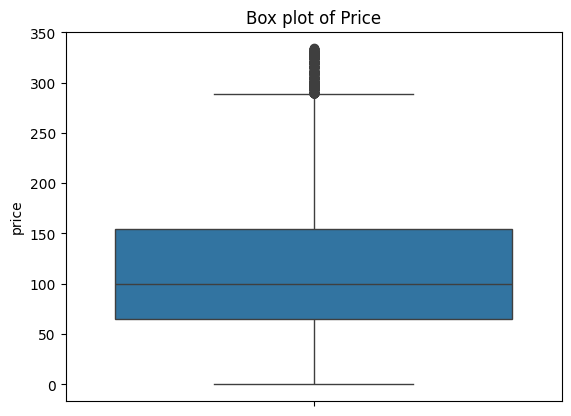

In [127]:
sns.boxplot(df['price'])
plt.title('Box plot of Price')
plt.show()

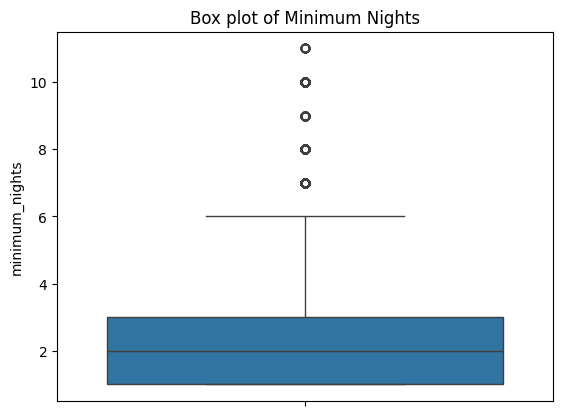

In [128]:
sns.boxplot(df['minimum_nights'])
plt.title('Box plot of Minimum Nights')
plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [129]:
# TODO: encode categorical columns appropriately
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39738 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             39738 non-null  object 
 1   neighbourhood                   39738 non-null  object 
 2   room_type                       39738 non-null  object 
 3   price                           39738 non-null  int64  
 4   minimum_nights                  39738 non-null  int64  
 5   number_of_reviews               39738 non-null  int64  
 6   reviews_per_month               39738 non-null  float64
 7   calculated_host_listings_count  39738 non-null  int64  
 8   availability_365                39738 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 3.0+ MB


In [130]:
# TODO: engineer at least two new features
#neighbourhood grp,neighbourhood and room type should be converted to numeric format
#by one hot encoding we convert the neighbourhood_group

In [131]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [132]:
df=pd.get_dummies(df,columns=['neighbourhood_group'],dtype=int)
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,Kensington,Private room,149,1,9,0.21,6,365,0,1,0,0,0
1,Midtown,Entire home/apt,225,1,45,0.38,2,355,0,0,1,0,0
2,Harlem,Private room,150,3,0,0.72,1,365,0,0,1,0,0
3,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194,0,1,0,0,0
4,East Harlem,Entire home/apt,80,10,9,0.10,1,0,0,0,1,0,0


In [133]:
df['neighbourhood'].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', "Hell's Kitchen", 'Upper West Side', 'Chinatown',
       'South Slope', 'Williamsburg', 'Fort Greene', 'Chelsea',
       'Crown Heights', 'Park Slope', 'Bedford-Stuyvesant',
       'Windsor Terrace', 'Inwood', 'Greenpoint', 'Bushwick', 'Flatbush',
       'Lower East Side', 'East Village', 'Long Island City', 'Kips Bay',
       'Upper East Side', 'Washington Heights', 'Prospect Heights',
       'Carroll Gardens', 'Prospect-Lefferts Gardens', 'Flatlands',
       'Cobble Hill', 'Flushing', 'West Village', 'DUMBO', 'Gowanus',
       'St. George', 'Highbridge', 'Financial District',
       'Morningside Heights', 'Jamaica', 'Ridgewood', 'Middle Village',
       'NoHo', 'Ditmars Steinway', 'Flatiron District',
       'Roosevelt Island', 'Greenwich Village', 'Little Italy',
       'East Flatbush', 'Tompkinsville', 'Astoria', 'Clason Point',
       'Eastchester', 'Boerum Hill', 'Brooklyn Heights', 'Tw

In [134]:
pip install category_encoders

In [135]:
import category_encoders as ce
target_encoder=ce.TargetEncoder(cols=['neighbourhood'])
df['neighbourhood'] = target_encoder.fit_transform(df['neighbourhood'], df['price'])
df

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,87.927689,Private room,149,1,9,0.21,6,365,0,1,0,0,0
1,178.863132,Entire home/apt,225,1,45,0.38,2,355,0,0,1,0,0
2,104.819408,Private room,150,3,0,0.72,1,365,0,0,1,0,0
3,125.760684,Entire home/apt,89,1,270,4.64,1,194,0,1,0,0,0
4,114.538304,Entire home/apt,80,10,9,0.10,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,96.194016,Private room,70,2,0,0.72,2,9,0,1,0,0,0
48891,81.895030,Private room,40,4,0,0.72,2,36,0,1,0,0,0
48892,104.819408,Entire home/apt,115,10,0,0.72,1,27,0,0,1,0,0
48893,160.006307,Shared room,55,1,0,0.72,6,2,0,0,1,0,0


In [136]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [137]:
from sklearn.preprocessing import OrdinalEncoder
encoder_room_type = OrdinalEncoder(categories= [['Entire home/apt', 'Private room', 'Shared room']])
df['room_type'] = encoder_room_type.fit_transform(df[['room_type']])
df

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,87.927689,1.0,149,1,9,0.21,6,365,0,1,0,0,0
1,178.863132,0.0,225,1,45,0.38,2,355,0,0,1,0,0
2,104.819408,1.0,150,3,0,0.72,1,365,0,0,1,0,0
3,125.760684,0.0,89,1,270,4.64,1,194,0,1,0,0,0
4,114.538304,0.0,80,10,9,0.10,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,96.194016,1.0,70,2,0,0.72,2,9,0,1,0,0,0
48891,81.895030,1.0,40,4,0,0.72,2,36,0,1,0,0,0
48892,104.819408,0.0,115,10,0,0.72,1,27,0,0,1,0,0
48893,160.006307,2.0,55,1,0,0.72,6,2,0,0,1,0,0


In [138]:
# Percentage of the year the listing is available
df["availability_ratio"] = df["availability_365"] / 365
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,availability_ratio
0,87.927689,1.0,149,1,9,0.21,6,365,0,1,0,0,0,1.000000
1,178.863132,0.0,225,1,45,0.38,2,355,0,0,1,0,0,0.972603
2,104.819408,1.0,150,3,0,0.72,1,365,0,0,1,0,0,1.000000
3,125.760684,0.0,89,1,270,4.64,1,194,0,1,0,0,0,0.531507
4,114.538304,0.0,80,10,9,0.10,1,0,0,0,1,0,0,0.000000


In [139]:
# Whether the listing has received at least one review
df["received_reviews"] = (df["number_of_reviews"] > 0).astype(int)
df.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,availability_ratio,received_reviews
0,87.927689,1.0,149,1,9,0.21,6,365,0,1,0,0,0,1.000000,1
1,178.863132,0.0,225,1,45,0.38,2,355,0,0,1,0,0,0.972603,1
2,104.819408,1.0,150,3,0,0.72,1,365,0,0,1,0,0,1.000000,0
3,125.760684,0.0,89,1,270,4.64,1,194,0,1,0,0,0,0.531507,1
4,114.538304,0.0,80,10,9,0.10,1,0,0,0,1,0,0,0.000000,1


**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

since number_of_reviews and reviews_per_month are based on information that we get only after guests have interacted with the listing and so should not be used as predictors.Including them could provide the model with information that would not be available at the time of prediction.


---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [140]:
# TODO: build Pipeline combining your cleaning, imputation, encoding, scaling steps

In [141]:
pip install category_encoders

In [142]:
import pandas as pd
import category_encoders as ce
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [143]:
# TODO: train/test split (before fitting anything)
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df_1 = pd.read_csv(url)
df_1.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [144]:
#missing value
df_1["reviews_per_month"] = df_1["reviews_per_month"].fillna(0)

In [145]:
df_1 = df_1.drop(columns=["id","name",'host_id',"host_name","last_review","latitude","longitude"])

In [146]:
print(df_1.columns.tolist())

['neighbourhood_group', 'neighbourhood', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


outliers


In [147]:
Q1=df['price'].quantile(0.25)
Q2=df['price'].quantile(0.5)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1

lower_bound_price = Q1- 1.5* IQR
upper_bound_price = Q3+ 1.5 *IQR

Q1_min_nights=df['minimum_nights'].quantile(0.25)
Q3_min_nights=df['minimum_nights'].quantile(0.75)
IQR_min_nights=Q3_min_nights-Q1_min_nights

lower_bound_min_nights=Q1_min_nights-1.5*IQR_min_nights
upper_bound_min_nights=Q3_min_nights+1.5*IQR_min_nights

df=df[((df['price'] >= lower_bound_price)& (df['price']<= upper_bound_price)) & \
                ((df['minimum_nights'] >= lower_bound_min_nights) & (df['minimum_nights'] <= upper_bound_min_nights))]

In [148]:
X = df_1.drop('price', axis=1)
y = df_1['price']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

In [149]:
categorical_col_1 = ['neighbourhood_group']
categorical_col_2 = ['room_type']
categorical_col_3 = ['neighbourhood']
numerical_cols = ['minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365',
     ]

In [150]:
# combine pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_col_1),
        ('ordinal', OrdinalEncoder(categories=[['Entire home/apt', 'Private room', 'Shared room']]), categorical_col_2),
        ('target', ce.TargetEncoder(cols=categorical_col_3), categorical_col_3)
    ])

In [151]:
# preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

In [152]:
# Fit and transform the training data
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

In [153]:
X_train_processed

array([[-1.93025322e-01, -2.77198099e-01, -1.39865617e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.44272698e+02],
       [-2.39596087e-01, -4.79450822e-01, -5.82445839e-01, ...,
         0.00000000e+00,  1.00000000e+00,  9.19421488e+01],
       [-2.39596087e-01, -5.24395871e-01, -6.82182228e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.07456923e+02],
       ...,
       [ 1.06438535e+00, -5.01923347e-01, -4.70242403e-01, ...,
         0.00000000e+00,  0.00000000e+00,  2.17275126e+02],
       [-2.39596087e-01, -2.77198099e-01, -6.01146412e-01, ...,
         0.00000000e+00,  0.00000000e+00,  2.17275126e+02],
       [-9.98837910e-02, -5.01923347e-01, -6.63481655e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.28609813e+02]])

In [154]:
X_test_processed

array([[-1.93025322e-01,  8.68900664e-01, -2.39602005e-01, ...,
         0.00000000e+00,  0.00000000e+00,  8.90216365e+01],
       [ 6.45248457e-01, -5.24395871e-01, -6.82182228e-01, ...,
         0.00000000e+00,  1.00000000e+00,  7.67859327e+01],
       [-2.39596087e-01, -1.42362950e-01, -4.14140684e-01, ...,
         0.00000000e+00,  1.00000000e+00,  2.06444656e+02],
       ...,
       [-2.86166853e-01, -4.12033248e-01, -1.71033238e-01, ...,
         0.00000000e+00,  1.00000000e+00,  9.27079646e+01],
       [-2.39596087e-01, -5.24395871e-01, -6.82182228e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.85661507e+02],
       [-1.93025322e-01,  1.04834822e-01, -4.76475927e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.85661507e+02]])

---
## Part 6 — Written Reflection

1. Unusual or extreme price values can have a significant impact on the machine learning model because price is the target variable we are trying to predict. Very high or very low prices can influence the model and may lead to less accurate predictions. Therefore, it is important to identify and carefully handle these unusual values before training the model.
2. When the model is used on new or live data, the same preprocessing steps used during training should also be applied. The rules and transformations should be based on the training data and then consistently applied to new data. This ensures that the new data is processed in the same way as the data used to train the model, helping the model make reliable predictions
3. Not every unusual or missing value is necessarily an error. Some of these values may represent real and meaningful information in the dataset. Therefore, instead of automatically deleting all unusual or missing values, they should be examined carefully. Removing too many values could result in the loss of useful information and reduce the amount of data available for training the model.